In [1]:
import torch
import pde_model_sde

import os, sys
sys.path.append('../src/')
import viz

In [2]:
d = 2
L = 4.0
options = {
    "d": d,
    "plot_dims": [0,1],
    "fixed_dims_vals": 0.0*torch.ones(d),
    "x_start": -L,
    "x_end": L,
}

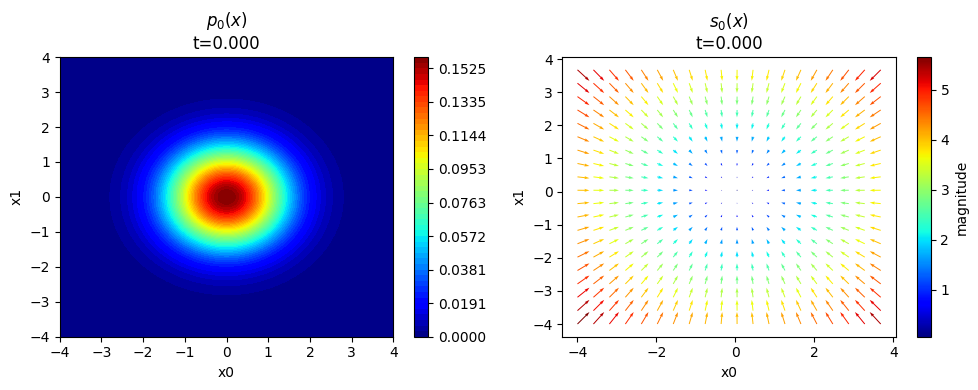

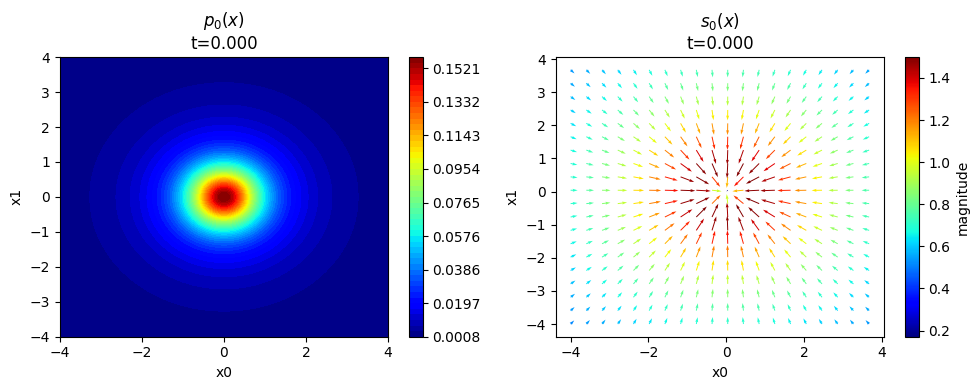

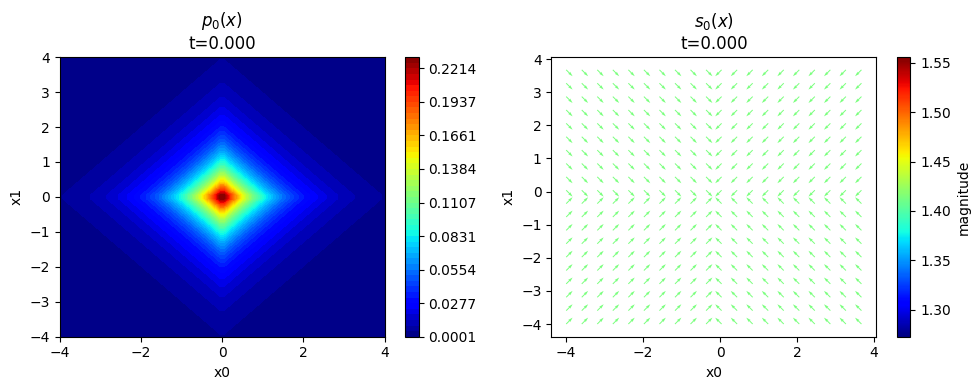

In [3]:
for model in [
    pde_model_sde.Gaussian_OU(d),
    pde_model_sde.Cauchy_OU(d),
    pde_model_sde.Laplace_OU(d)
]:
    p_ic = lambda X: model.initial_dist.p0(X[:,:-1])
    s_ic = lambda X: model.initial_dist.s0(X[:,:-1])
    plotter = viz.FunctionPlotter(**options)
    plotter.add_panel('ic', title=r"$p_0(x)$").heatmap(p_ic)
    plotter.add_panel('ic', title=r"$s_0(x)$").quiver(s_ic)
    plotter.show_plot(t_val=0.0)